In [114]:
import sys
import os

# Obtener el directorio padre (ruta base del proyecto)
base_path = os.path.abspath('..')
if base_path not in sys.path:
    sys.path.append(base_path)

import paths
import pandas as pd

# # Rutas del proyecto
data_dir = paths.data_dir()
avance2_base = paths.fase2_fil_dir()


Lectura del contenido del dataset

In [115]:
dataset_path = os.path.join(avance2_base, 'imagenes_tipo.csv')
df = pd.read_csv(dataset_path)
df.head()

,ruta_imagen,tipo
0,/train/images/1392_png.rf.0cff93c4891cf1412de9...,NBH
1,/train/images/1212_png.rf.a92f0931457738e80f3a...,NBH
2,/train/images/370_png.rf.673d7f6e0b494b45d56e4...,NBH
3,/train/images/274_png.rf.e90cadb44ae6d5806228a...,NBH
4,/train/images/235_JPG.rf.00e4c988557c651c507ee...,NBH


In [116]:
# Mostramos los valores únicos de la columna 'tipo'
print("Valores únicos en la columna 'tipo':")
print(df['tipo'].unique())

Valores únicos en la columna 'tipo':
<StringArray>
['NBH', 'NBF', 'BH', 'BF']
Length: 4, dtype: str


In [117]:
# Generamos un conteo de cada tipo de imagen
conteo_tipos = df['tipo'].value_counts()
print("\nConteo de cada tipo de imagen:")
print(conteo_tipos)


Conteo de cada tipo de imagen:
tipo
BF     1078
NBF     418
BH      149
NBH      45
Name: count, dtype: int64


In [118]:
# Nombres completos para cada tipo de imagen

nombre_tipo = {
    'BF':'Bosque con fuego',
    'BH': 'Bosque con humo',
    'NBF': 'No Bosque con fuego',
    'NBH': 'No Bosque con humo',
}

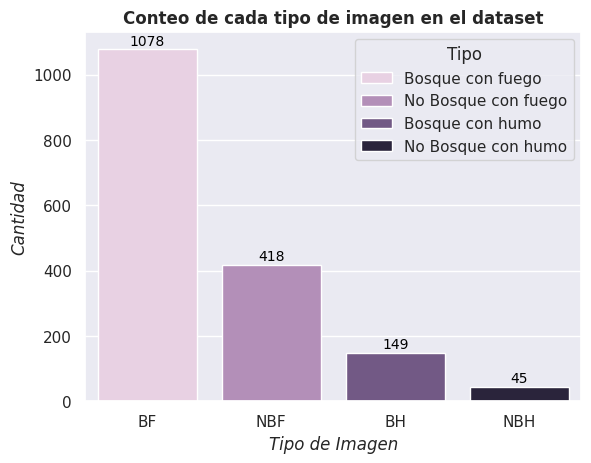

<Figure size 640x480 with 0 Axes>

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme()

# Convertimos los codigos de clase a etiquetas legibles
etiquetas_tipos = conteo_tipos.index.map(nombre_tipo)

# Grafico de barras para el conteo de cada tipo de imagen
palette = sns.cubehelix_palette(rot=.2, n_colors=len(conteo_tipos))
ax = sns.barplot(
    x=conteo_tipos.index,
    y=conteo_tipos.values,
    hue=conteo_tipos.index,
    legend=True,
    palette=palette,
)

# Renombramos la leyenda usando el diccionario de nombres completos
handles, labels = ax.get_legend_handles_labels()
new_labels = [nombre_tipo.get(label, label) for label in labels]
ax.legend(handles=handles, labels=new_labels, title='Tipo')

# Agregamos la cantidad encima de cada barra 
for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        ax.annotate(
            f'{int(altura)}',
            (p.get_x() + p.get_width() / 2., altura),
            ha='center',
            va='center',
            fontsize=10,
            color='black',
            xytext=(0, 6),
            textcoords='offset points'
        )

plt.xlabel('Tipo de Imagen', fontdict={'style': 'italic'})
plt.ylabel('Cantidad', fontdict={'style': 'italic'})
plt.title('Conteo de cada tipo de imagen en el dataset', fontdict={'weight': 'bold'})
plt.show()

# Guardamos el gráfico
grafico_path = os.path.join(avance2_base, 'figuras/conteo_tipos_imagenes.png')
plt.savefig(grafico_path, dpi=300, bbox_inches='tight')